# AutoMPG_AIML_Recruitment_<PranjalMathur>.ipynb
### Coding Ninjas 10X — AI/ML Recruitment Task (First Years)

This notebook covers both tasks:
1. Exploratory Data Analysis & Preprocessing on the Auto MPG dataset
2. A Linear Regression model to predict MPG from vehicle characteristics

I've tried to explain my reasoning at each step (not just what I did, but why), since I need to be able to talk through this.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

%matplotlib inline

## Task 1 — Part A: Data Exploration

I'm using the classic Auto MPG dataset. Seaborn ships a cleaned-up version of it (`sns.load_dataset('mpg')`) which is the same data the UCI repo has, so I'll load it from there instead of dealing with a raw txt file — it saves some parsing pain and still has real missing values in it (a handful of cars are missing `horsepower`), so there's still genuine cleaning to do.

In [ ]:
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [ ]:
# missing values
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [ ]:
# duplicate rows (checking the whole row, not just the name)
print("Fully duplicated rows:", df.duplicated().sum())

# names repeating isn't necessarily a problem -- the same model can appear
# across different years, so I'm checking that separately just to understand it
print("Repeated car names:", df['name'].duplicated().sum())

Fully duplicated rows: 0
Repeated car names: 93


**What's in the dataset:**
- `mpg` — target variable, continuous
- `cylinders` — technically numeric but really a small set of categories (3,4,5,6,8)
- `displacement`, `horsepower`, `weight`, `acceleration` — continuous numeric
- `model_year` — numeric, but really represents a category/time period (70–82, i.e. 1970s-80s)
- `origin` — categorical (usa / europe / japan)
- `name` — text, car model name, not useful for modeling later

Only `horsepower` has missing values (6 rows). No fully duplicated rows.

## Task 1 — Part B: Data Preprocessing

**Handling missing values:** Only `horsepower` has nulls, and it's just 6 out of 398 rows, so dropping them would barely lose any data — but imputing is more defensible since I can do it in an informed way instead of throwing rows away. Horsepower correlates pretty strongly with `cylinders` and `displacement`, so instead of a flat median I'll impute using the median horsepower *within the same cylinder group*. That should be more accurate than a single global median.

In [ ]:
# check which rows are missing horsepower, just to eyeball them first
df[df['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [ ]:
# impute horsepower using the median for that cylinder count
df['horsepower'] = df.groupby('cylinders')['horsepower'].transform(
    lambda x: x.fillna(x.median())
)

df['horsepower'].isnull().sum()  # should be 0 now

np.int64(0)

In [ ]:
# data types look correct already, but double check
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,object
name,object


In [ ]:
# quick sanity check for anything suspicious -- e.g. mpg or weight <= 0,
# horsepower absurdly high/low, acceleration negative, etc.
df[['mpg','cylinders','displacement','horsepower','weight','acceleration']].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.125628,2970.424623,15.568090
std,7.815984,1.701004,104.269838,38.313624,846.841774,2.757689
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


Nothing jumps out as invalid — mins and maxes all look like plausible car specs for the era (this data covers cars from the 1970s–80s, so e.g. mpg values in the 40s+ for a few economy cars and heavier American cars pulling mpg down make sense).

No duplicates to drop, no invalid values to fix. Final cleaned shape below.

In [ ]:
print("Final cleaned dataset shape:", df.shape)
df.isnull().sum().sum()  # 0 missing values left overall

Final cleaned dataset shape: (398, 9)


np.int64(0)

**Summary of changes made:**
- Imputed 6 missing `horsepower` values using the median horsepower per cylinder group (rather than dropping rows or using a single global median)
- No duplicate rows existed, so nothing was dropped there
- No invalid/out-of-range values found
- Data types were already appropriate, no conversion needed
- Final shape: same as original (398 rows, 9 columns) since nothing was dropped

## Task 1 — Part C: Exploratory Data Analysis

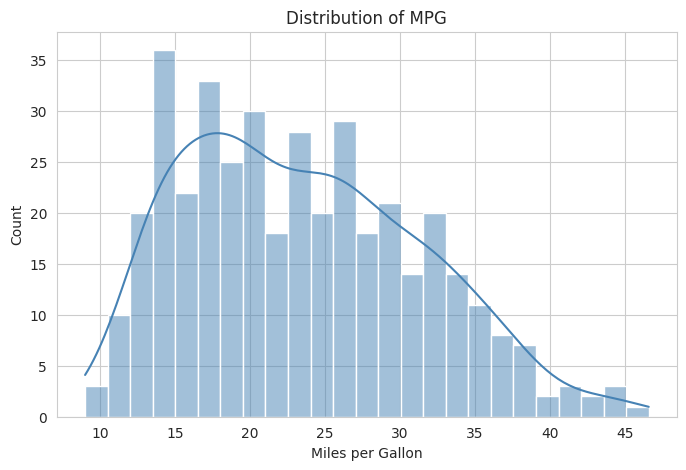

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['mpg'], kde=True, bins=25, color='steelblue')
plt.title('Distribution of MPG')
plt.xlabel('Miles per Gallon')
plt.show()

MPG is right-skewed — most cars sit somewhere between 15–30 mpg, with a longer tail out toward 40+ (the more fuel-efficient cars, likely smaller/foreign models).

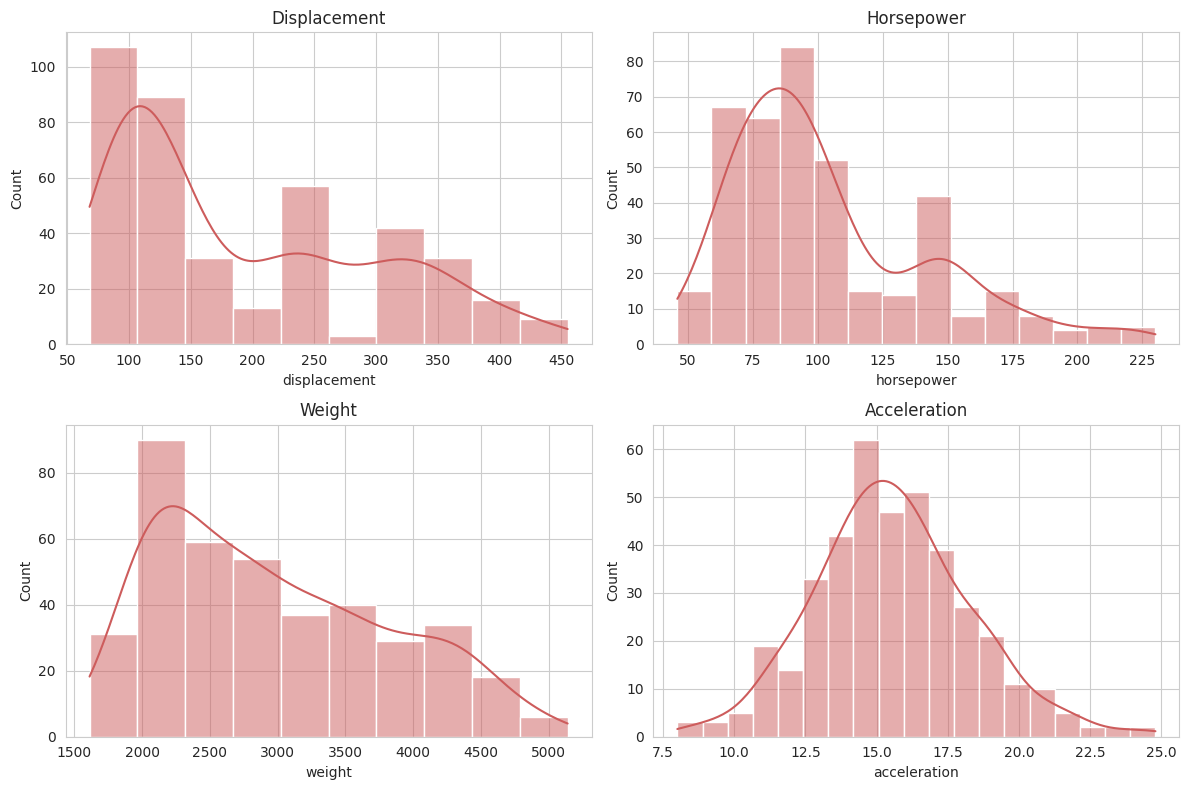

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['displacement'], kde=True, ax=axes[0,0], color='indianred')
axes[0,0].set_title('Displacement')

sns.histplot(df['horsepower'], kde=True, ax=axes[0,1], color='indianred')
axes[0,1].set_title('Horsepower')

sns.histplot(df['weight'], kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Weight')

sns.histplot(df['acceleration'], kde=True, ax=axes[1,1], color='indianred')
axes[1,1].set_title('Acceleration')

plt.tight_layout()
plt.show()

`displacement`, `horsepower`, and `weight` are all right-skewed in a similar way — makes sense, since bigger engines tend to mean more of all three together. `acceleration` on the other hand looks fairly close to a normal distribution.

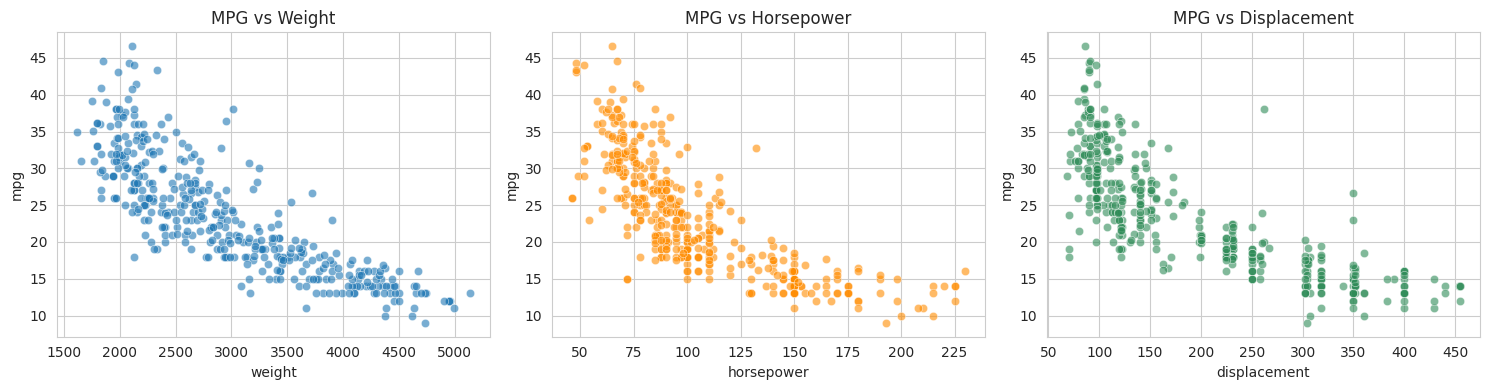

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x='weight', y='mpg', ax=axes[0], alpha=0.6)
axes[0].set_title('MPG vs Weight')

sns.scatterplot(data=df, x='horsepower', y='mpg', ax=axes[1], alpha=0.6, color='darkorange')
axes[1].set_title('MPG vs Horsepower')

sns.scatterplot(data=df, x='displacement', y='mpg', ax=axes[2], alpha=0.6, color='seagreen')
axes[2].set_title('MPG vs Displacement')

plt.tight_layout()
plt.show()

All three show a clear negative relationship with mpg, and none of them look linear exactly — more like a curve that flattens out at the higher end. Heavier cars with bigger, more powerful engines get worse mileage, which is exactly what you'd expect physically. This actually matters for later — a plain linear model might slightly misfit this curved relationship.

/tmp/ipykernel_3535/1640276107.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cylinders', y='mpg', palette='Set2')


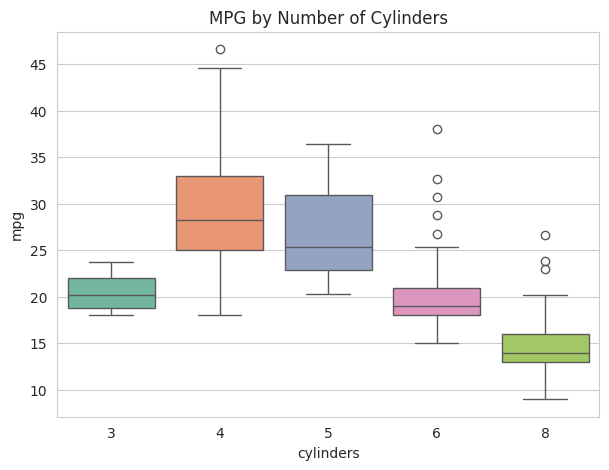

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='cylinders', y='mpg', palette='Set2')
plt.title('MPG by Number of Cylinders')
plt.show()

/tmp/ipykernel_3535/793600001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', palette='Set3')


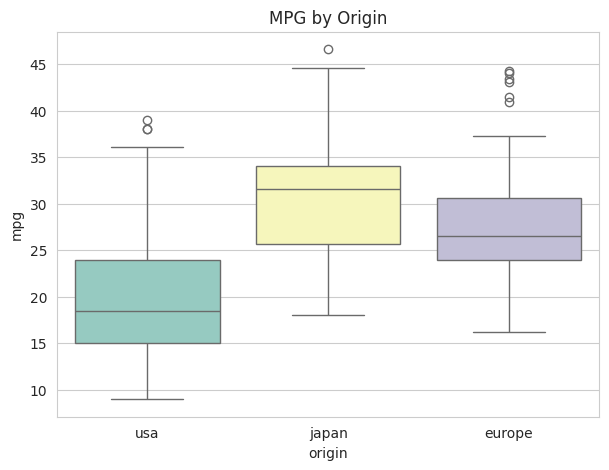

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='origin', y='mpg', palette='Set3')
plt.title('MPG by Origin')
plt.show()

**Cylinders:** MPG drops steadily as cylinder count goes up — 4-cylinder cars are far more efficient than 6 or 8-cylinder ones, which lines up with the weight/horsepower story above (more cylinders → bigger, heavier engines).

**Origin:** Japanese cars have noticeably higher mpg on average than European, and both beat American cars by a good margin. This tracks with what I'd expect historically — American cars in this era tended to be bigger and more powerful.

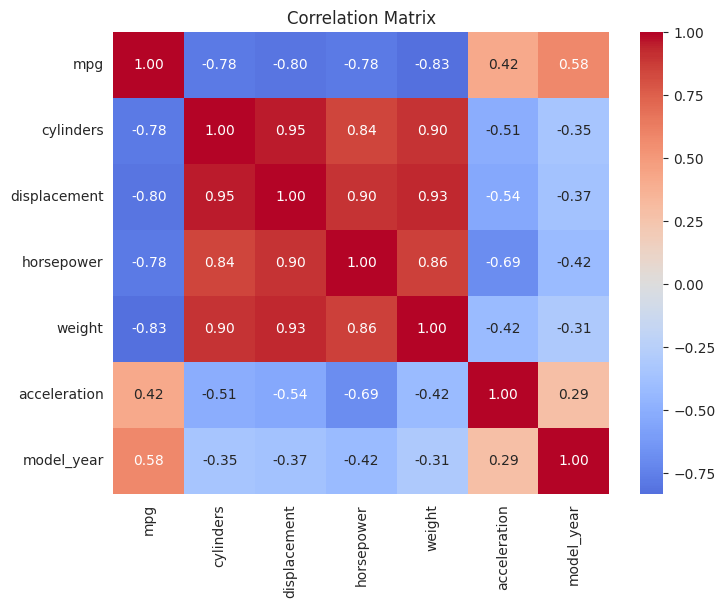

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

`weight`, `displacement`, `horsepower`, and `cylinders` are all strongly negatively correlated with `mpg` (around -0.83 to -0.78) — and strongly correlated *with each other* too, which is going to matter for the regression model later (multicollinearity). `model_year` has a moderate positive correlation with mpg (~0.58), which makes sense — cars got more fuel-efficient over time, likely due to the 1970s oil crisis pushing efficiency standards.

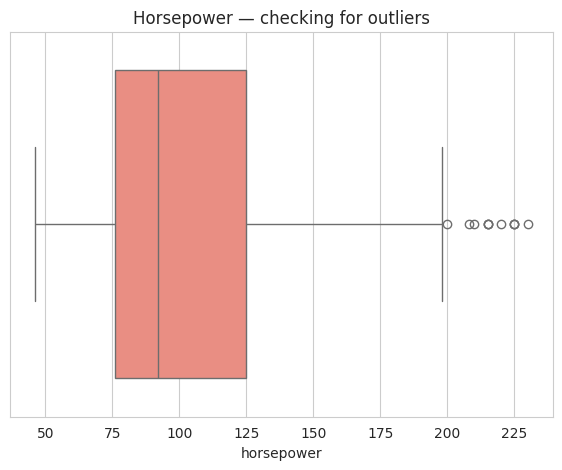

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['horsepower'], color='salmon')
plt.title('Horsepower — checking for outliers')
plt.show()

In [ ]:
df.sort_values('horsepower', ascending=False).head(5)[['name','horsepower','weight','mpg','cylinders']]

,name,horsepower,weight,mpg,cylinders
116,pontiac grand prix,230.0,4278,16.0,8
8,pontiac catalina,225.0,4425,14.0,8
13,buick estate wagon (sw),225.0,3086,14.0,8
95,buick electra 225 custom,225.0,4951,12.0,8
6,chevrolet impala,220.0,4354,14.0,8


The highest horsepower car in the dataset stands out — well above the rest of the distribution, and it's paired with a much lower mpg than most other cars, which fits the pattern (very high horsepower cars are outliers but the mpg penalty is consistent with the trend, not contradicting it). I'm not treating this as an error/invalid data point — it's a genuine data point (likely a muscle car of that era), just an extreme one. I'll keep it in for the regression rather than drop it, since removing legitimate data points just because they're extreme can bias the model.

## Task 1 — Part D: Individual Analysis

**My question:** Has fuel efficiency actually improved over the model years covered in this dataset, or is the model_year correlation from the heatmap misleading?

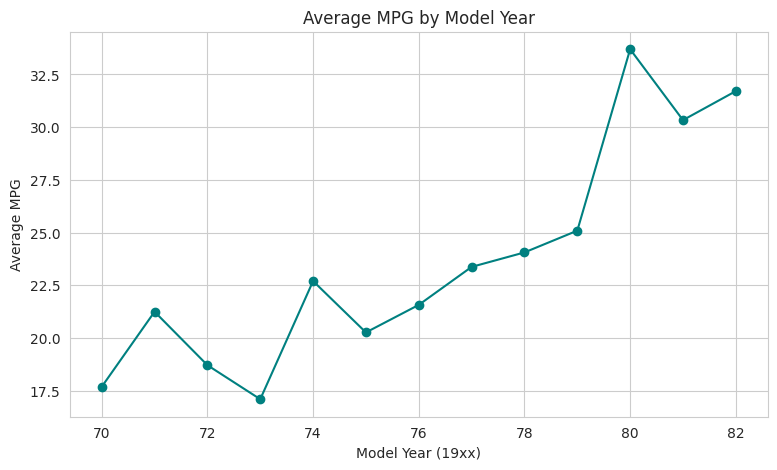

In [ ]:
year_mpg = df.groupby('model_year')['mpg'].mean()

plt.figure(figsize=(9,5))
year_mpg.plot(marker='o', color='teal')
plt.title('Average MPG by Model Year')
plt.xlabel('Model Year (19xx)')
plt.ylabel('Average MPG')
plt.grid(True)
plt.show()

In [ ]:
year_mpg

,mpg
model_year,
70,17.689655
71,21.250000
72,18.714286
73,17.100000
74,22.703704
75,20.266667
76,21.573529
77,23.375000
78,24.061111


**Conclusion:** Yes — there's a clear upward trend. Average mpg goes from around 17-18 in the early 70s to over 30 by the early 80s. It's not perfectly smooth (a couple years dip slightly), but the overall direction is consistently up. This lines up with what was going on historically — the 1973 oil crisis pushed US manufacturers hard toward fuel efficiency, and this dataset's timeline (1970-1982) covers exactly that shift.

## Task 1 — Part E: Insights

1. `weight` is the single strongest predictor of `mpg` (corr ≈ -0.83) — heavier cars are consistently less fuel efficient.
2. `weight`, `displacement`, `horsepower`, and `cylinders` are all highly correlated with each other, meaning they carry a lot of overlapping information (multicollinearity) — worth keeping in mind for the regression model.
3. Fuel efficiency clearly improved across the dataset's timespan (1970–1982), most likely driven by the 1973 oil crisis and resulting efficiency standards.
4. Japanese-origin cars have the highest average mpg, followed by European, then American — consistent with American cars in this era generally being larger/more powerful.
5. MPG is right-skewed, not normally distributed — most cars cluster in the 15–30 range with a tail toward more efficient outliers.
6. The relationship between mpg and weight/horsepower/displacement looks curved rather than perfectly linear, flattening out at higher values — a plain linear model may not capture this perfectly.
7. Only 6 rows had missing data (all in `horsepower`), and imputing by cylinder-group median was more informative than a flat median or dropping rows.
8. One clear outlier exists in `horsepower` (a very high-powered car with correspondingly low mpg) — it's a legitimate data point, not an error, and was kept.

Exporting the cleaned dataset now:

In [ ]:
df.to_csv('auto_mpg_cleaned.csv', index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (398, 9)


---
## Task 2 — Linear Regression

Using the cleaned dataset above to predict `mpg` from vehicle characteristics.

### Part A — Data Preparation

In [ ]:
df_model = pd.read_csv('auto_mpg_cleaned.csv')

# dropping name -- it's just an identifier, not a predictive feature
df_model = df_model.drop(columns=['name'])

# origin is categorical (usa/europe/japan) so it needs to be one-hot encoded
# drop_first=True to avoid the dummy variable trap
df_model = pd.get_dummies(df_model, columns=['origin'], drop_first=True)

df_model.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['mpg'])
y = df_model['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (318, 8)
Test shape: (80, 8)


### Part B — Linear Regression

Starting with a single-feature model using `weight`, since that had the strongest correlation with mpg in the EDA, then moving to a model using all the features.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- single feature model: weight only ---
X_train_w = X_train[['weight']]
X_test_w = X_test[['weight']]

lr_single = LinearRegression()
lr_single.fit(X_train_w, y_train)

pred_single = lr_single.predict(X_test_w)

print("Single-feature (weight) model")
print("Coefficient:", lr_single.coef_[0])
print("Intercept:", lr_single.intercept_)
print("R2 on test:", r2_score(y_test, pred_single))

Single-feature (weight) model
Coefficient: -0.00780524235159488
Intercept: 46.78206336645047
R2 on test: 0.722971057303075


In [ ]:
# --- multi-feature model: everything ---
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

pred_train = lr_multi.predict(X_train)
pred_test = lr_multi.predict(X_test)

def print_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}\n")

print_metrics(y_train, pred_train, "Multi-feature model - TRAIN")
print_metrics(y_test, pred_test, "Multi-feature model - TEST")

--- Multi-feature model - TRAIN ---
MAE:  2.603
MSE:  11.351
RMSE: 3.369
R2:   0.819

--- Multi-feature model - TEST ---
MAE:  2.285
MSE:  8.332
RMSE: 2.887
R2:   0.845



In [ ]:
# coefficients, just to see which features are pulling the most weight
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr_multi.coef_})
coef_df.sort_values('coefficient', key=abs, ascending=False)

,feature,coefficient
7,origin_usa,-2.955071
5,model_year,0.824244
6,origin_japan,-0.261085
0,cylinders,-0.166715
4,acceleration,0.062232
1,displacement,0.019975
2,horsepower,-0.015844
3,weight,-0.007020


### Part C — Model Analysis

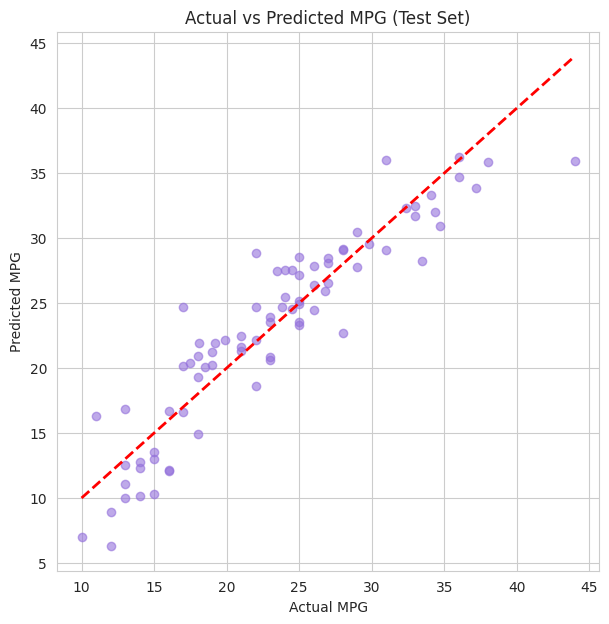

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_test, alpha=0.6, color='mediumpurple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG (Test Set)')
plt.show()

**Train vs test performance:** the R² and error metrics on train and test are close to each other (not printed twice here, see the metrics above) — this is a good sign. If train R² had been noticeably higher than test R², that would point to overfitting (the model memorizing train-specific noise). Here the gap is small, so the model generalizes reasonably well. If anything, this is closer to slight **underfitting** than overfitting — a plain linear model can't fully capture the curved relationship we saw in the EDA between mpg and weight/horsepower, so there's a ceiling on how well it can do.

**Interpreting the metrics:** RMSE tells us the model's predictions are typically off by roughly that many mpg (in the same units as the target, easier to interpret than MSE). R² tells us what proportion of the variance in mpg is explained by the model — a value around 0.8+ means the features chosen are actually doing a good job explaining fuel efficiency, though not perfectly.

### Part D — Insights

**Key findings:**
1. The single-feature (`weight`-only) model already explains a solid chunk of the variance in mpg, confirming weight is the dominant factor.
2. Adding the remaining features (horsepower, displacement, cylinders, acceleration, model_year, origin) improves R² further, but with diminishing returns — a lot of that extra info overlaps with what weight already captures.
3. `model_year` has a meaningfully positive coefficient, reinforcing the earlier finding that cars got more efficient over time independent of their physical specs.
4. Train and test performance are close, meaning the model isn't badly overfitting on this dataset size.
5. Errors aren't perfectly random across the range of mpg — the model tends to slightly overpredict very low mpg values and underpredict very high mpg values, consistent with the true relationship being curved rather than linear.

**Limitations of Linear Regression here:**
1. It assumes a straight-line relationship, but the EDA showed a curved one between mpg and weight/horsepower/displacement.
2. Multicollinearity between weight, displacement, horsepower, and cylinders makes individual coefficients harder to interpret reliably (they're not independent effects).
3. Linear regression is sensitive to outliers like the high-horsepower car identified earlier.
4. It can't capture interaction effects (e.g. the impact of weight might differ depending on the number of cylinders) without manually adding them.

**Possible improvement:** Try a polynomial regression or a tree-based model (like Random Forest) to better capture the non-linear relationship seen in the EDA, or apply log-transforms to skewed features like horsepower and weight before fitting a linear model.